# Map integration

In [3]:
import folium
from folium.plugins import MarkerCluster
import pandas as pd
import numpy as np
import webbrowser
from scipy.sparse import csr_matrix
import networkx as nx

In [4]:
edges = pd.read_csv("../data/edges.csv").rename(columns=lambda x: x.strip())[["# source", "target", "distance"]].drop_duplicates()
nodes = pd.read_csv("../data/nodes.csv").rename(columns=lambda x: x.strip())
nodes = nodes[["name","city","country","latitude","longitude","altitude"]]

In [ ]:
nodes.head()

,id,name,city,country,latitude,longitude,altitude
0,1,Goroka Airport,Goroka,Papua New Guinea,-6.081690,145.391998,5282
1,2,Madang Airport,Madang,Papua New Guinea,-5.207080,145.789001,20
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,-5.826790,144.296005,5388
3,4,Nadzab Airport,Nadzab,Papua New Guinea,-6.569803,146.725977,239
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,-9.443380,147.220001,146


In [204]:
class Map:
    def __init__(self, center, zoom_start):
        self.center = center
        self.zoom_start = zoom_start
        self.m = folium.Map(location=self.center, zoom_start=self.zoom_start, tiles="cartodb positron", prefer_canvas=True)
        self.nodes = None
    
    def add_nodes(self, nodes):
        marker_cluster = MarkerCluster().add_to(self.m)
        for i, row in nodes.iterrows():
            folium.Marker(
                location=[row["latitude"], row["longitude"]],
                popup=row["name"] 
            ).add_to(marker_cluster)
        self.nodes = nodes
    
    # NOVÁ METÓDA PODĽA TVOJHO ZADANIA
    def add_edges(self, edges_df, color="blue", weight=2):
        for i, row in edges_df.iterrows():
            start = [float(x) for x in row["start"].split(",")]
            end = [float(x) for x in row["end"].split(",")]
            
            folium.PolyLine(
                locations=[start, end],
                color=color,
                weight=weight,
                opacity=0.7 if color != "gray" else 0.5, # Sivé necháme viac priehľadné
                tooltip=f"Let: {row['# source']} -> {row['target']}"
            ).add_to(self.m)
            
    def showMap(self, filename):
        self.m.save(filename)
        webbrowser.open(filename)

In [14]:
for c in sorted(nodes["country"].unique()):
    print(c)

Afghanistan
Albania
Algeria
American Samoa
Angola
Anguilla
Antigua and Barbuda
Argentina
Armenia
Aruba
Australia
Austria
Azerbaijan
Bahamas
Bahrain
Bangladesh
Barbados
Belarus
Belgium
Belize
Benin
Bermuda
Bhutan
Bolivia
Bosnia and Herzegovina
Botswana
Brazil
British Virgin Islands
Brunei
Bulgaria
Burkina Faso
Burma
Burundi
Cambodia
Cameroon
Canada
Cape Verde
Cayman Islands
Central African Republic
Chad
Chile
China
Christmas Island
Cocos (Keeling) Islands
Colombia
Comoros
Congo (Brazzaville)
Congo (Kinshasa)
Cook Islands
Costa Rica
Cote d'Ivoire
Croatia
Cuba
Cyprus
Czech Republic
Denmark
Djibouti
Dominica
Dominican Republic
East Timor
Ecuador
Egypt
El Salvador
Equatorial Guinea
Eritrea
Estonia
Ethiopia
Falkland Islands
Faroe Islands
Fiji
Finland
France
French Guiana
French Polynesia
Gabon
Gambia
Georgia
Germany
Ghana
Gibraltar
Greece
Greenland
Grenada
Guadeloupe
Guam
Guatemala
Guernsey
Guinea
Guinea-Bissau
Guyana
Haiti
Honduras
Hong Kong
Hungary
Iceland
India
Indonesia
Iran
Iraq
Ireland

In [72]:
def vykresli_komponenty(moja_mapa, edges_df, components):
    # 1. Pre istotu vytvoríme kópiu a pretypujeme ID na čísla, aby fungovalo porovnávanie
    df = edges_df.copy()
    df["source_id"] = df["source_id"].astype(int)
    df["target_id"] = df["target_id"].astype(int)
    
    # 2. MAIN KOMPONENT (Čierna farba)
    main_nodes = components[0]
    # Nájdeme riadky, kde je aspoň jeden z vrcholov v main komponente
    mask_main = df['source_id'].isin(main_nodes) | df['target_id'].isin(main_nodes)
    
    # Vykreslíme len tieto vyfiltrované hrany
    moja_mapa.add_edges(df[mask_main], color="black", weight=3)
    
    # Odstránime ich z DataFrameu, aby sme ich už ďalej neriešili
    df = df[~mask_main]
    
    # 3. OSTATNÉ KOMPONENTY (Farebné)
    color_palette = [
        'blue', 'red', 'green', 'purple', 'orange', 'darkred',
        'cadetblue', 'darkblue', 'darkgreen', 'darkpurple', 'pink'
    ]
    
    # Cyklus začína od indexu 1, pretože index 0 (main) už máme vybavený
    for i, comp_nodes in enumerate(components[1:]):
        farba = color_palette[i % len(color_palette)]
        
        # Nájdeme hrany pre tento konkrétny komponent
        mask_comp = df['source_id'].isin(comp_nodes) | df['target_id'].isin(comp_nodes)
        
        # Vykreslíme
        moja_mapa.add_edges(df[mask_comp], color=farba, weight=3)
        
        # Opäť ich odstránime z balíka
        df = df[~mask_comp]
        
    # 4. ZVYŠNÉ HRANY (Sivá farba)
    # Všetko, čo v 'df' zostalo, nepatrí do žiadneho zadaného komponentu
    if not df.empty:
        moja_mapa.add_edges(df, color="gray", weight=1.5)

In [74]:
slovakia_airports = [1264]
slovakia_edges = edges.query("`# source` in @slovakia_airports or target in @slovakia_airports")

In [75]:
slovakia_edges.count()

# source    148
target      148
distance    148
dtype: int64

In [ ]:
def make_start_end(edges_df):
    new_edges = edges_df.copy()
    new_edges[["start","end"]] = new_edges[["# source", "target"]].apply(lambda row: 
                                           f"{nodes.loc[row['# source'],'latitude']}," +
                                           f"{nodes.loc[row['# source'],'longitude']};"+
                                           f"{nodes.loc[row['target'],'latitude']},"+
                                           f"{nodes.loc[row['target'],'longitude']}", axis=1).str.split(";",expand=True)
    return new_edges

In [ ]:
mapa = Map((48.14, 17.10), zoom_start=5)
mapa.add_nodes(nodes)
mapa.add_edges(edges)
mapa.showMap(True)

In [79]:
from math import sin, cos, sqrt, atan2, radians

def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371.0  # Radius of the Earth in km
    
    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    # Haversine formula
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    
    return R * c

In [ ]:
calculate_distance(50.1008,14.26,48.17020034790039,17.21269989013672)

303.64758166571426

In [ ]:
components = [#main_component
    [931, 932, 933, 934, 935, 936, 937, 2535, 2536, 2537],
    [1282, 1285, 1300, 2605],
    [1837, 2426, 2970, 2971],
    [1903, 2643, 3022, 3023],
    [2380, 2382, 2905, 3097],
    [1279, 2603],
    [1295, 2877],
    [1296, 3048],
    [2072, 2300],
    [2259, 3116],
    [1267],
    [1272],
    [1273],
    [1274],
    [1277],
    [1283],
    [1284],
    [1287],
    [1291],
    [1292],
    [1297],
    [1299],
    [2606],
    [3049],
]# articulation point = 1264
moja_mapa = Map(center=[48.1486, 17.1077], zoom_start=4)

# moja_mapa.add_nodes(nodes_df) # Tvoje uzly

# Zavolanie novej funkcie (edges_df je tvoj dataframe letov)
vykresli_komponenty(moja_mapa, edges, components)

# Zobrazenie
moja_mapa.showMap(open_map=True)

In [49]:
bridges = [(4, 2242),
 (4, 2249),
 (4, 2257),
 (7, 14),
 (9, 2265),
 (10, 14),
 (11, 14),
 (12, 14),
 (21, 113),
 (33, 88),
 (33, 131),
 (33, 2148),
 (34, 106),
 (34, 2308),
 (34, 3120),
 (37, 126),
 (38, 125),
 (54, 113),
 (57, 2292),
 (58, 3118),
 (63, 97),
 (69, 113),
 (78, 2298),
 (78, 3120),
 (93, 106),
 (95, 2311),
 (97, 116),
 (97, 127),
 (97, 2318),
 (97, 2332),
 (97, 3119),
 (103, 113),
 (121, 2290),
 (125, 128),
 (126, 2271),
 (126, 2310),
 (126, 2320),
 (126, 3045),
 (133, 138),
 (133, 150),
 (133, 2340),
 (142, 2338),
 (144, 2339),
 (156, 157),
 (156, 158),
 (156, 159),
 (156, 2341),
 (161, 165),
 (161, 166),
 (161, 172),
 (161, 173),
 (167, 170),
 (168, 170),
 (170, 3185),
 (183, 254),
 (184, 2906),
 (201, 205),
 (206, 597),
 (210, 618),
 (215, 216),
 (217, 218),
 (218, 220),
 (218, 223),
 (218, 225),
 (218, 227),
 (218, 232),
 (218, 233),
 (218, 372),
 (241, 261),
 (244, 2352),
 (254, 633),
 (270, 272),
 (270, 277),
 (270, 2344),
 (270, 2353),
 (275, 279),
 (279, 717),
 (295, 297),
 (295, 298),
 (295, 299),
 (307, 2203),
 (308, 327),
 (311, 315),
 (313, 315),
 (315, 323),
 (315, 324),
 (346, 369),
 (349, 368),
 (357, 364),
 (357, 368),
 (359, 368),
 (363, 368),
 (363, 2371),
 (381, 384),
 (381, 386),
 (381, 387),
 (381, 388),
 (381, 389),
 (381, 391),
 (381, 398),
 (381, 460),
 (397, 440),
 (402, 403),
 (402, 415),
 (409, 410),
 (409, 2373),
 (418, 421),
 (429, 433),
 (433, 439),
 (433, 2377),
 (446, 2378),
 (452, 453),
 (461, 2384),
 (462, 463),
 (467, 3209),
 (471, 3209),
 (482, 2385),
 (488, 492),
 (505, 2391),
 (508, 517),
 (522, 526),
 (529, 533),
 (533, 2398),
 (533, 2399),
 (533, 3108),
 (535, 538),
 (538, 539),
 (540, 541),
 (542, 544),
 (544, 2405),
 (544, 2896),
 (546, 548),
 (546, 3187),
 (549, 2407),
 (551, 2408),
 (551, 3072),
 (564, 2111),
 (570, 583),
 (570, 2888),
 (570, 2889),
 (578, 581),
 (578, 2470),
 (597, 641),
 (600, 611),
 (607, 629),
 (614, 625),
 (615, 629),
 (628, 721),
 (629, 637),
 (629, 638),
 (649, 1952),
 (651, 1952),
 (660, 1952),
 (666, 2126),
 (669, 1952),
 (692, 741),
 (692, 743),
 (698, 706),
 (718, 719),
 (718, 3117),
 (732, 734),
 (738, 739),
 (744, 750),
 (745, 770),
 (749, 750),
 (750, 752),
 (760, 2907),
 (760, 2910),
 (770, 2478),
 (770, 3168),
 (770, 3173),
 (797, 799),
 (797, 2086),
 (809, 832),
 (811, 832),
 (814, 832),
 (822, 832),
 (826, 1715),
 (827, 832),
 (831, 832),
 (832, 835),
 (832, 839),
 (832, 842),
 (832, 2485),
 (863, 3107),
 (863, 2486),
 (863, 2909),
 (866, 2490),
 (868, 2487),
 (868, 2934),
 (878, 879),
 (887, 1736),
 (888, 1736),
 (892, 898),
 (895, 898),
 (896, 898),
 (898, 2491),
 (902, 2494),
 (902, 2495),
 (902, 2496),
 (903, 2502),
 (904, 2051),
 (904, 2497),
 (904, 2499),
 (904, 2504),
 (907, 2506),
 (909, 1838),
 (918, 921),
 (930, 2514),
 (930, 2526),
 (930, 2528),
 (931, 934),
 (934, 935),
 (934, 936),
 (934, 2537),
 (939, 946),
 (939, 947),
 (939, 958),
 (939, 962),
 (939, 2505),
 (941, 944),
 (956, 959),
 (959, 961),
 (977, 988),
 (981, 982),
 (982, 987),
 (997, 1000),
 (1000, 2540),
 (1000, 2541),
 (1000, 2542),
 (1000, 2543),
 (1000, 2883),
 (1000, 2884),
 (1000, 3088),
 (1008, 2193),
 (1016, 1018),
 (1020, 1021),
 (1023, 1026),
 (1025, 1034),
 (1026, 1030),
 (1034, 2555),
 (1050, 1055),
 (1053, 1485),
 (1061, 1102),
 (1062, 1102),
 (1068, 1080),
 (1071, 1102),
 (1078, 1102),
 (1086, 1102),
 (1091, 1102),
 (1092, 1102),
 (1100, 1102),
 (1101, 1102),
 (1102, 1681),
 (1102, 2573),
 (1102, 2575),
 (1102, 2576),
 (1102, 3213),
 (1105, 2577),
 (1105, 2578),
 (1111, 1113),
 (1115, 1116),
 (1115, 1121),
 (1115, 1987),
 (1115, 2132),
 (1115, 2585),
 (1115, 2586),
 (1115, 2587),
 (1115, 2588),
 (1115, 2589),
 (1115, 2590),
 (1115, 2591),
 (1115, 2592),
 (1115, 2871),
 (1120, 2583),
 (1129, 1132),
 (1131, 1132),
 (1132, 1136),
 (1132, 1137),
 (1132, 1138),
 (1132, 1139),
 (1132, 1142),
 (1132, 1143),
 (1132, 1145),
 (1132, 1152),
 (1132, 1161),
 (1132, 3157),
 (1162, 3053),
 (1162, 3126),
 (1163, 1199),
 (1165, 1180),
 (1167, 1206),
 (1167, 3054),
 (1168, 2873),
 (1169, 3058),
 (1170, 1183),
 (1173, 1177),
 (1178, 3062),
 (1180, 1234),
 (1180, 2613),
 (1180, 3061),
 (1180, 3182),
 (1181, 1215),
 (1183, 1226),
 (1183, 1227),
 (1183, 3055),
 (1183, 3066),
 (1183, 3067),
 (1192, 2062),
 (1199, 3064),
 (1199, 3128),
 (1202, 3126),
 (1210, 1212),
 (1223, 1230),
 (1223, 2594),
 (1224, 2062),
 (1226, 1229),
 (1226, 3131),
 (1226, 3132),
 (1226, 3133),
 (1231, 2598),
 (1248, 3183),
 (1252, 1253),
 (1253, 2599),
 (1256, 1257),
 (1257, 1258),
 (1257, 1259),
 (1262, 2602),
 (1264, 1267),
 (1264, 1272),
 (1264, 1273),
 (1264, 1274),
 (1264, 1277),
 (1264, 1279),
 (1264, 1283),
 (1264, 1284),
 (1264, 1287),
 (1264, 1291),
 (1264, 1292),
 (1264, 1295),
 (1264, 1297),
 (1264, 1299),
 (1264, 2606),
 (1264, 3049),
 (1266, 1280),
 (1270, 1271),
 (1270, 1275),
 (1279, 2603),
 (1280, 2604),
 (1289, 1294),
 (1295, 2877),
 (1303, 1304),
 (1303, 3046),
 (1307, 2607),
 (1307, 2608),
 (1313, 1317),
 (1314, 1317),
 (1315, 1317),
 (1316, 1317),
 (1317, 1319),
 (1317, 1322),
 (1317, 1326),
 (1317, 2609),
 (1317, 2610),
 (1317, 3181),
 (1330, 1340),
 (1332, 1344),
 (1333, 1340),
 (1334, 1340),
 (1336, 1340),
 (1338, 1340),
 (1340, 1342),
 (1340, 1345),
 (1340, 1348),
 (1340, 1350),
 (1344, 1346),
 (1352, 2177),
 (1361, 1363),
 (1363, 2920),
 (1370, 1371),
 (1388, 2624),
 (1388, 2625),
 (1388, 2626),
 (1393, 1437),
 (1395, 3150),
 (1399, 2635),
 (1399, 2928),
 (1399, 3160),
 (1401, 2630),
 (1405, 2631),
 (1408, 2931),
 (1429, 2221),
 (1435, 2930),
 (1437, 2661),
 (1437, 2846),
 (1445, 1446),
 (1445, 1450),
 (1445, 1454),
 (1445, 1459),
 (1445, 1494),
 (1447, 1513),
 (1463, 2669),
 (1463, 3171),
 (1464, 3171),
 (1466, 2063),
 (1471, 2670),
 (1478, 1484),
 (1480, 1484),
 (1484, 2673),
 (1490, 1493),
 (1493, 1498),
 (1493, 1499),
 (1493, 2878),
 (1493, 2891),
 (1506, 2053),
 (1506, 2097),
 (1506, 2098),
 (1508, 1509),
 (1509, 1510),
 (1509, 1511),
 (1509, 2117),
 (1509, 2118),
 (1509, 2674),
 (1509, 2675),
 (1509, 2676),
 (1512, 1516),
 (1513, 1514),
 (1513, 3100),
 (1526, 1529),
 (1526, 1531),
 (1526, 1535),
 (1526, 1537),
 (1526, 1539),
 (1526, 1540),
 (1526, 1946),
 (1526, 1947),
 (1526, 2092),
 (1526, 2093),
 (1526, 2172),
 (1526, 2680),
 (1528, 1919),
 (1542, 2686),
 (1545, 2106),
 (1545, 2107),
 (1549, 1557),
 (1551, 2690),
 (1551, 2691),
 (1552, 1553),
 (1557, 2690),
 (1558, 1568),
 (1558, 1570),
 (1558, 3194),
 (1562, 1563),
 (1562, 1564),
 (1562, 3197),
 (1567, 1920),
 (1567, 3195),
 (1567, 3196),
 (1574, 1576),
 (1579, 1581),
 (1583, 1584),
 (1589, 1929),
 (1599, 1680),
 (1600, 1607),
 (1608, 1612),
 (1610, 1985),
 (1610, 2141),
 (1612, 1620),
 (1612, 2728),
 (1614, 2729),
 (1621, 1639),
 (1623, 2723),
 (1623, 2758),
 (1625, 2723),
 (1626, 2720),
 (1627, 2034),
 (1627, 2714),
 (1627, 2716),
 (1627, 2749),
 (1627, 2750),
 (1627, 2755),
 (1627, 2764),
 (1631, 1633),
 (1633, 1634),
 (1633, 2724),
 (1633, 2748),
 (1633, 2751),
 (1633, 3199),
 (1634, 2752),
 (1639, 1640),
 (1639, 2042),
 (1639, 2734),
 (1639, 2741),
 (1639, 2915),
 (1639, 2916),
 (1652, 2784),
 (1656, 2794),
 (1656, 2795),
 (1656, 2796),
 (1656, 2797),
 (1656, 3077),
 (1656, 3089),
 (1658, 2800),
 (1658, 3081),
 (1658, 3085),
 (1667, 3080),
 (1671, 3158),
 (1671, 3174),
 (1674, 1675),
 (1675, 2827),
 (1675, 2829),
 (1675, 2885),
 (1675, 2935),
 (1675, 3177),
 (1675, 3212),
 (1679, 2579),
 (1684, 1815),
 (1685, 1752),
 (1688, 2987),
 (1689, 2565),
 (1692, 1861),
 (1693, 1765),
 (1695, 2952),
 (1696, 1702),
 (1697, 1715),
 (1698, 2948),
 (1699, 1734),
 (1699, 1821),
 (1699, 2012),
 (1699, 2013),
 (1699, 2457),
 (1699, 2460),
 (1699, 2844),
 (1702, 1742),
 (1704, 2461),
 (1708, 2155),
 (1710, 1800),
 (1712, 1825),
 (1712, 1877),
 (1712, 2066),
 (1715, 2058),
 (1715, 2969),
 (1715, 2991),
 (1715, 2992),
 (1716, 2079),
 (1718, 2452),
 (1719, 2994),
 (1719, 2995),
 (1723, 1800),
 (1730, 1779),
 (1733, 1853),
 (1735, 1861),
 (1735, 3003),
 (1735, 3005),
 (1738, 1881),
 (1738, 2009),
 (1738, 2156),
 (1738, 2431),
 (1738, 2451),
 (1738, 2966),
 (1738, 2967),
 (1743, 1907),
 (1744, 1852),
 (1744, 2465),
 (1753, 1999),
 (1754, 2414),
 (1754, 2468),
 (1754, 2927),
 (1758, 1854),
 (1761, 1806),
 (1763, 2006),
 (1765, 2978),
 (1765, 2979),
 (1767, 2008),
 (1772, 1800),
 (1782, 1861),
 (1789, 2424),
 (1789, 2453),
 (1789, 2918),
 (1791, 1901),
 (1798, 1861),
 (1799, 1806),
 (1800, 1807),
 (1800, 1820),
 (1800, 1824),
 (1800, 1832),
 (1800, 1844),
 (1800, 1859),
 (1800, 2154),
 (1800, 2207),
 (1806, 2423),
 (1806, 2438),
 (1806, 2464),
 (1806, 2921),
 (1809, 1846),
 (1809, 2153),
 (1809, 2159),
 (1809, 2194),
 (1809, 2411),
 (1809, 2420),
 (1809, 2447),
 (1809, 2450),
 (1809, 2463),
 (1809, 2466),
 (1813, 2412),
 (1815, 3011),
 (1829, 2444),
 (1834, 2926),
 (1836, 1907),
 (1837, 2426),
 (1850, 2954),
 (1853, 1871),
 (1853, 2151),
 (1853, 2196),
 (1853, 2197),
 (1853, 2418),
 (1853, 2439),
 (1853, 2441),
 (1853, 2459),
 (1853, 2924),
 (1853, 2925),
 (1853, 2953),
 (1853, 2962),
 (1854, 1993),
 (1855, 1885),
 (1861, 1897),
 (1861, 1908),
 (1861, 2559),
 (1861, 2879),
 (1866, 2115),
 (1868, 3001),
 (1868, 2892),
 (1868, 2894),
 (1868, 3000),
 (1871, 2467),
 (1872, 1914),
 (1875, 2997),
 (1875, 2998),
 (1875, 3028),
 (1885, 1890),
 (1885, 2082),
 (1885, 2229),
 (1885, 2413),
 (1885, 2427),
 (1885, 2430),
 (1885, 2446),
 (1886, 2988),
 (1886, 3038),
 (1886, 3039),
 (1897, 2893),
 (1897, 3026),
 (1897, 3027),
 (1901, 2167),
 (1901, 2410),
 (1903, 2643),
 (1903, 3022),
 (1903, 3023),
 (1913, 1916),
 (1913, 2445),
 (1913, 2941),
 (1919, 1950),
 (1919, 2094),
 (1926, 2703),
 (1937, 2693),
 (1940, 1951),
 (1944, 2056),
 (1944, 2110),
 (1952, 2123),
 (1952, 2124),
 (1952, 2125),
 (1952, 2471),
 (1967, 2016),
 (1968, 1969),
 (1973, 1980),
 (1977, 1979),
 (1978, 1979),
 (1988, 2267),
 (1988, 2268),
 (1990, 3076),
 (1991, 2738),
 (1991, 2739),
 (2006, 3093),
 (2008, 2434),
 (2008, 2959),
 (2008, 2963),
 (2008, 2964),
 (2016, 2634),
 (2016, 2638),
 (2016, 2639),
 (2016, 2640),
 (2016, 2665),
 (2016, 2666),
 (2016, 2872),
 (2016, 3146),
 (2016, 3148),
 (2048, 2230),
 (2048, 2233),
 (2048, 2236),
 (2048, 2237),
 (2072, 2300),
 (2085, 2142),
 (2115, 2454),
 (2135, 2582),
 (2135, 2947),
 (2147, 2530),
 (2183, 2479),
 (2193, 2913),
 (2201, 2351),
 (2213, 2632),
 (2222, 2637),
 (2259, 3116),
 (2265, 2267),
 (2268, 3144),
 (2278, 2293),
 (2287, 2317),
 (2287, 2330),
 (2292, 2330),
 (2380, 2382),
 (2391, 2392),
 (2393, 3069),
 (2463, 2641),
 (2480, 2481),
 (2517, 2525),
 (2521, 2525),
 (2525, 2898),
 (2562, 2567),
 (2562, 2853),
 (2565, 3034),
 (2566, 2858),
 (2567, 2974),
 (2567, 2975),
 (2567, 3037),
 (2633, 3159),
 (2644, 3210),
 (2698, 2699),
 (2717, 2761),
 (2717, 2762),
 (2721, 2738),
 (2729, 3198),
 (2737, 2738),
 (2761, 2993),
 (2767, 3075),
 (2771, 3203),
 (2773, 3202),
 (2790, 3104),
 (2793, 2794),
 (2851, 3178),
 (2867, 2987),
 (2895, 3029),
 (2914, 2916),
 (2972, 3024),
 (2973, 3019),
 (3004, 3005),
 (3052, 3058),
 (3052, 3129),
 (3057, 3129),
 (3125, 3127)]



In [51]:
edges.columns

Index(['# source', 'target', 'distance', 'airline', 'start', 'end'], dtype='str')

In [57]:
moja_druha = Map(center=[48.1486, 17.1077], zoom_start=4)
edges["route"] = edges[["# source", "target"]].apply(lambda row: (row["# source"], row["target"]), axis=1)
not_bridge_edges = edges[edges["route"].apply(lambda x: x not in bridges)]
bridge_edges = edges[edges["route"].apply(lambda x: x in bridges)]
moja_druha.add_edges(not_bridge_edges,"gray")
moja_druha.add_edges(bridge_edges,"red")

In [59]:
moja_druha.showMap("bridges.html")

In [82]:
edges.columns

Index(['# source', 'target', 'distance', 'start', 'end'], dtype='str')

In [83]:
A = np.array([[0 for i in range(3214)] for i in range(3214)])

for source, target, distance,_,_ in edges.values:
    A[np.int16(source)][np.int16(target)] = distance

In [ ]:
G = nx.from_numpy_array(A, create_using=nx.DiGraph)

In [94]:
G_real = nx.from_pandas_edgelist(edges, source='# source', target='target', create_using=nx.DiGraph).to_undirected()

# Zistíme základné parametre
N = G_real.number_of_nodes()
M = G_real.number_of_edges()

print(f"Reálna sieť má {N} vrcholov a {M} hrán.")

Reálna sieť má 3214 vrcholov a 18859 hrán.


In [95]:
# --- 1. Erdős–Rényi (ER) ---
# Vypočítame pravdepodobnosť 'p' tak, aby sme mali v priemere rovnaký počet hrán M.
# Maximálny možný počet hrán je N * (N - 1) / 2.
p = (2 * M) / (N * (N - 1))

G_er = nx.erdos_renyi_graph(n=N, p=p, seed=42)
print(f"ER graf vygenerovaný: {G_er.number_of_edges()} hrán.")


# --- 2. Barabási–Albert (BA) ---
# Parameter 'm' určuje, koľko hrán vytvorí každý nový vrchol pri pridaní do siete.
# Keďže každý vrchol pridá 'm' hrán, celkový počet hrán bude zhruba N * m.
# Preto m vypočítame ako M / N (zaokrúhlené na celé číslo).
m = int(round(M / N))

# Poistka, BA model vyžaduje aby m >= 1 a m < N
if m < 1: m = 1 

G_ba = nx.barabasi_albert_graph(n=N, m=m, seed=42)
print(f"BA graf vygenerovaný: {G_ba.number_of_edges()} hrán.")

ER graf vygenerovaný: 18642 hrán.
BA graf vygenerovaný: 19248 hrán.


In [96]:
def vypocitaj_statistiku(G, nazov_siete):
    print(f"\n--- Štatistika pre: {nazov_siete} ---")
    
    # 1. Priemerný zhlukový koeficient (Clustering Coefficient)
    # Meria, aká je šanca, že ak A letí do B a A letí do C, tak existuje let aj medzi B a C.
    cc = nx.average_clustering(G)
    print(f"Zhlukový koeficient: {cc:.4f}")
    
    # 2. Priemerná najkratšia cesta
    # POZOR: Toto funguje len na súvislých grafoch! Preto si musíme zobrať 
    # len najväčší súvislý komponent (Giant Component).
    giant_component_nodes = max(nx.connected_components(G), key=len)
    G_giant = G.subgraph(giant_component_nodes)
    
    avg_path = nx.average_shortest_path_length(G_giant)
    print(f"Priemerná dĺžka najkratšej cesty: {avg_path:.4f}")

# Spustíme výpočty
vypocitaj_statistiku(G_real, "Reálna letecká sieť")
vypocitaj_statistiku(G_er, "Erdős–Rényi (Náhodný)")
vypocitaj_statistiku(G_ba, "Barabási–Albert (Huby)")


--- Štatistika pre: Reálna letecká sieť ---
Zhlukový koeficient: 0.4918
Priemerná dĺžka najkratšej cesty: 3.9585

--- Štatistika pre: Erdős–Rényi (Náhodný) ---
Zhlukový koeficient: 0.0041
Priemerná dĺžka najkratšej cesty: 3.5708

--- Štatistika pre: Barabási–Albert (Huby) ---
Zhlukový koeficient: 0.0201
Priemerná dĺžka najkratšej cesty: 3.1644


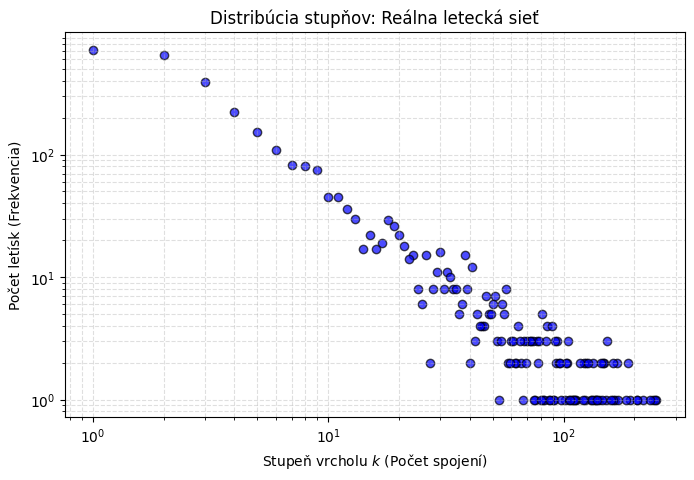

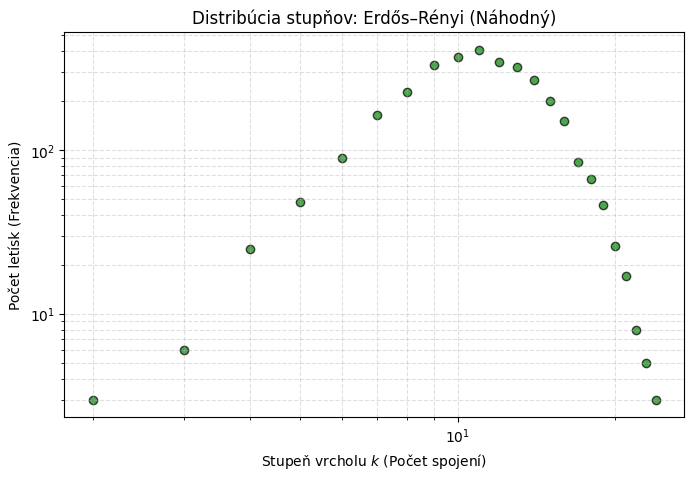

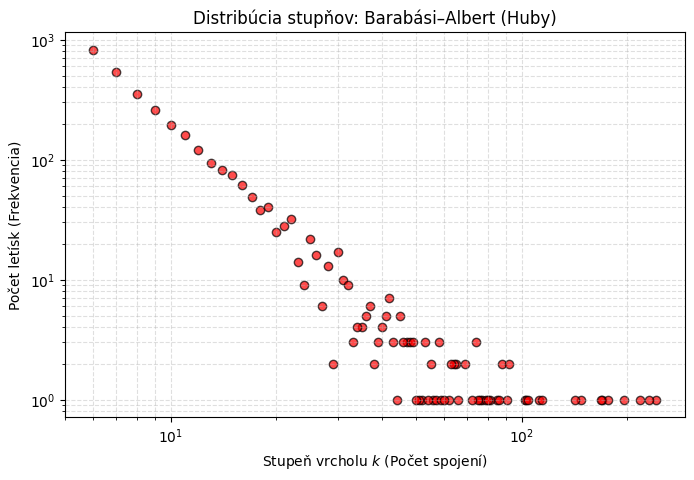

In [209]:
import matplotlib.pyplot as plt
from collections import Counter

def vykresli_distribuciu_stupnov(G, nazov_siete, farba):
    # 1. Získame zoznam stupňov pre všetky vrcholy v grafe
    stupne = [G.degree(n) for n in G.nodes()]
    
    # 2. Spočítame, koľko letísk má aký stupeň (napr. koľko letísk má presne 1 let, 2 lety, atď.)
    pocetnost_stupnov = Counter(stupne)
    
    # Rozdelíme to na os X (stupeň) a os Y (počet letísk s týmto stupňom)
    x = list(pocetnost_stupnov.keys())
    y = list(pocetnost_stupnov.values())
    
    # 3. Vykreslenie
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color=farba, alpha=0.7, edgecolors="black")
    
    plt.title(f"Distribúcia stupňov: {nazov_siete}")
    plt.xlabel("Stupeň vrcholu $k$ (Počet spojení)")
    plt.ylabel("Počet letísk (Frekvencia)")
    
    # Nastavenie logaritmickej mierky (kľúčové pre scale-free siete)
    plt.xscale('log')
    plt.yscale('log')
    
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.show()

# Vykreslíme grafy pre všetky tri siete, ktoré sme si predtým vygenerovali
vykresli_distribuciu_stupnov(G_real, "Reálna letecká sieť", "blue")
vykresli_distribuciu_stupnov(G_er, "Erdős–Rényi (Náhodný)", "green")
vykresli_distribuciu_stupnov(G_ba, "Barabási–Albert (Huby)", "red")

In [ ]:
# 1. Získame presnú postupnosť stupňov (degree sequence) z vašej reálnej siete
# Vráti zoznam čísel, napr. [1, 5, 2, 10, ...]
postupnost_stupnov = [stupen for vrchol, stupen in G_real.degree()]

# 2. Vygenerujeme konfiguračný model
# Výsledkom je MultiGraph (môže obsahovať slučky a násobné hrany)
G_conf_multi = nx.configuration_model(postupnost_stupnov)

# 3. Prevedieme MultiGraph na obyčajný Graph (odstráni násobné hrany)
G_conf = nx.Graph(G_conf_multi)

# 4. Odstránime slučky (self-loops)
G_conf.remove_edges_from(nx.selfloop_edges(G_conf))

print(f"Počet hrán - Reálna sieť: {G_real.number_of_edges()}")
print(f"Počet hrán - Konfiguračný model: {G_conf.number_of_edges()}")

18859
Počet hrán - Reálna sieť: 18859
Počet hrán - Konfiguračný model: 17918


In [108]:
def analyzuj_siet(G, nazov_siete):
    print(f"\n{'='*50}")
    print(f"HĹBKOVÁ ANALÝZA: {nazov_siete}")
    print(f"{'='*50}")
    
    # 1. NAJVÄČŠÍ SÚVISLÝ KOMPONENT (Giant Component)
    # Pre výpočet ciest musíme pracovať len s letiskami, ktoré sú navzájom prepojené
    komponenty = sorted(nx.connected_components(G), key=len, reverse=True)
    G_giant = G.subgraph(komponenty[0])
    
    print(f"Celkový počet uzlov: {G.number_of_nodes()}")
    print(f"Uzlov v Giant komponente: {G_giant.number_of_nodes()} " 
          f"({(G_giant.number_of_nodes()/G.number_of_nodes())*100:.1f}% zo siete)\n")

    # 2. GLOBÁLNE VLASTNOSTI SIETE
    # Zhlukový koeficient: Ako veľmi sú susedia prepojení medzi sebou?
    cc = nx.average_clustering(G)
    print(f"Priemerný zhlukový koeficient: {cc:.4f}")

    # Priemerná najkratšia cesta (počíta sa len na Giant komponente)
    avg_path = nx.average_shortest_path_length(G_giant)
    print(f"Priemerná dĺžka najkratšej cesty: {avg_path:.2f} krokov (prestupov)\n")

    # 3. LOKÁLNE VLASTNOSTI (CENTRALITY)
    # A) Degree Centrality (Normalizovaný stupeň) - "Lokálna popularita"
    deg_cent = nx.degree_centrality(G)
    top5_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:5]
    
    print("Top 5 letísk podľa Degree Centrality (najviac priamych spojení):")
    for letisko, hodnota in top5_deg:
        print(f" - Uzol {letisko}: {hodnota:.4f}")

    # B) Betweenness Centrality - "Úzke hrdlá / Tranzitné uzly"
    # POZOR: Pri sieti s tisíckami uzlov toto môže trvať 1-2 minúty výpočtového času!
    print("\nPočítam Betweenness Centrality (toto chvíľu potrvá)...")
    bet_cent = nx.betweenness_centrality(G_giant)
    top5_bet = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:5]
    
    print("Top 5 letísk podľa Betweenness Centrality (najčastejšie na najkratšej ceste):")
    for letisko, hodnota in top5_bet:
        print(f" - Uzol {letisko}: {hodnota:.4f}")

# --- POUŽITIE FUNKCIE ---
# Analyzujeme reálnu sieť
analyzuj_siet(G_real, "Reálna OpenFlights sieť")

# Analyzujeme konfiguračný model z predchádzajúceho kroku
analyzuj_siet(G_conf, "Konfiguračný model (Nulový model)")


HĹBKOVÁ ANALÝZA: Reálna OpenFlights sieť
Celkový počet uzlov: 3214
Uzlov v Giant komponente: 3188 (99.2% zo siete)

Priemerný zhlukový koeficient: 0.4918
Priemerná dĺžka najkratšej cesty: 3.96 krokov (prestupov)

Top 5 letísk podľa Degree Centrality (najviac priamych spojení):
 - Uzol 282: 0.0772
 - Uzol 191: 0.0759
 - Uzol 628: 0.0747
 - Uzol 770: 0.0725
 - Uzol 1809: 0.0675

Počítam Betweenness Centrality (toto chvíľu potrvá)...
Top 5 letísk podľa Betweenness Centrality (najčastejšie na najkratšej ceste):
 - Uzol 628: 0.0646
 - Uzol 1715: 0.0615
 - Uzol 1861: 0.0594
 - Uzol 1017: 0.0563
 - Uzol 191: 0.0533

HĹBKOVÁ ANALÝZA: Konfiguračný model (Nulový model)
Celkový počet uzlov: 3214
Uzlov v Giant komponente: 3210 (99.9% zo siete)

Priemerný zhlukový koeficient: 0.0692
Priemerná dĺžka najkratšej cesty: 3.32 krokov (prestupov)

Top 5 letísk podľa Degree Centrality (najviac priamych spojení):
 - Uzol 59: 0.0657
 - Uzol 54: 0.0654
 - Uzol 62: 0.0644
 - Uzol 343: 0.0613
 - Uzol 251: 0.05

In [ ]:
dict(zip(nodes.index.astype(int), nodes.iterrows()))

{0: (0,
  name           Goroka Airport
  city                   Goroka
  country      Papua New Guinea
  latitude             -6.08169
  longitude          145.391998
  altitude                 5282
  Name: 0, dtype: object),
 1: (1,
  name           Madang Airport
  city                   Madang
  country      Papua New Guinea
  latitude             -5.20708
  longitude          145.789001
  altitude                   20
  Name: 1, dtype: object),
 2: (2,
  name         Mount Hagen Kagamuga Airport
  city                          Mount Hagen
  country                  Papua New Guinea
  latitude                         -5.82679
  longitude                      144.296005
  altitude                             5388
  Name: 2, dtype: object),
 3: (3,
  name           Nadzab Airport
  city                   Nadzab
  country      Papua New Guinea
  latitude            -6.569803
  longitude          146.725977
  altitude                  239
  Name: 3, dtype: object),
 4: (4,
  name      

In [197]:
def match_edges(array, edges_df, nodes_df):
    # 1. Rýchly lookup slovník pre existujúce vzdialenosti
    id_to_name = dict(
        zip(
            zip(edges_df["# source"].astype(int), edges_df["target"].astype(int)),
            edges_df["distance"]
        )
    )
    
    # List, do ktorého budeme zbierať výsledky (rýchlejšie ako DataFrame)
    data_list = []

    for u, v in array:
        # Skúsime nájsť vzdialenosť v slovníku
        d = id_to_name.get((u, v))
        
        # Ak v pôvodných dátach nie je, vypočítame ju
        if d is None:
            try:
                # Predpokladáme, že nodes má ID ako index
                lon1, lat1 = nodes_df.loc[u, ["longitude", "latitude"]]
                lon2, lat2 = nodes_df.loc[v, ["longitude", "latitude"]]
                d = calculate_distance(lon1, lat1, lon2, lat2)
            except KeyError:
                print(f"Varovanie: Letisko {u} alebo {v} nebolo nájdené v tabuľke nodes.")
                d = None
        
        data_list.append({"# source": u, "target": v, "distance": d})

    # Vytvoríme DataFrame naraz na konci
    return pd.DataFrame(data_list)

In [202]:
match_edges(G_ba.edges,edges,nodes)

,# source,target,distance
0,0,1,106.747399
1,0,2,124.520121
2,0,3,157.150822
3,0,4,424.726096
4,0,5,296.416236
...,...,...,...
19243,3062,3064,529.291152
19244,3073,3076,4013.261908
19245,3129,3173,10729.919314
19246,3169,3183,18947.662581


In [ ]:
map_ba = Map((50,0),5)


map_ba.add_nodes(nodes)
map_ba.add_edges(make_start_end(match_edges(G_ba.edges, edges, nodes)))
map_ba.showMap("barabasi_map.html")


In [207]:
G_er.number_of_edges()

18642

In [203]:
map_er = Map((50,0),5)


map_er.add_nodes(nodes)
map_er.add_edges(make_start_end(match_edges(G_er.edges, edges, nodes)))
map_er.showMap("erdos_map.html")